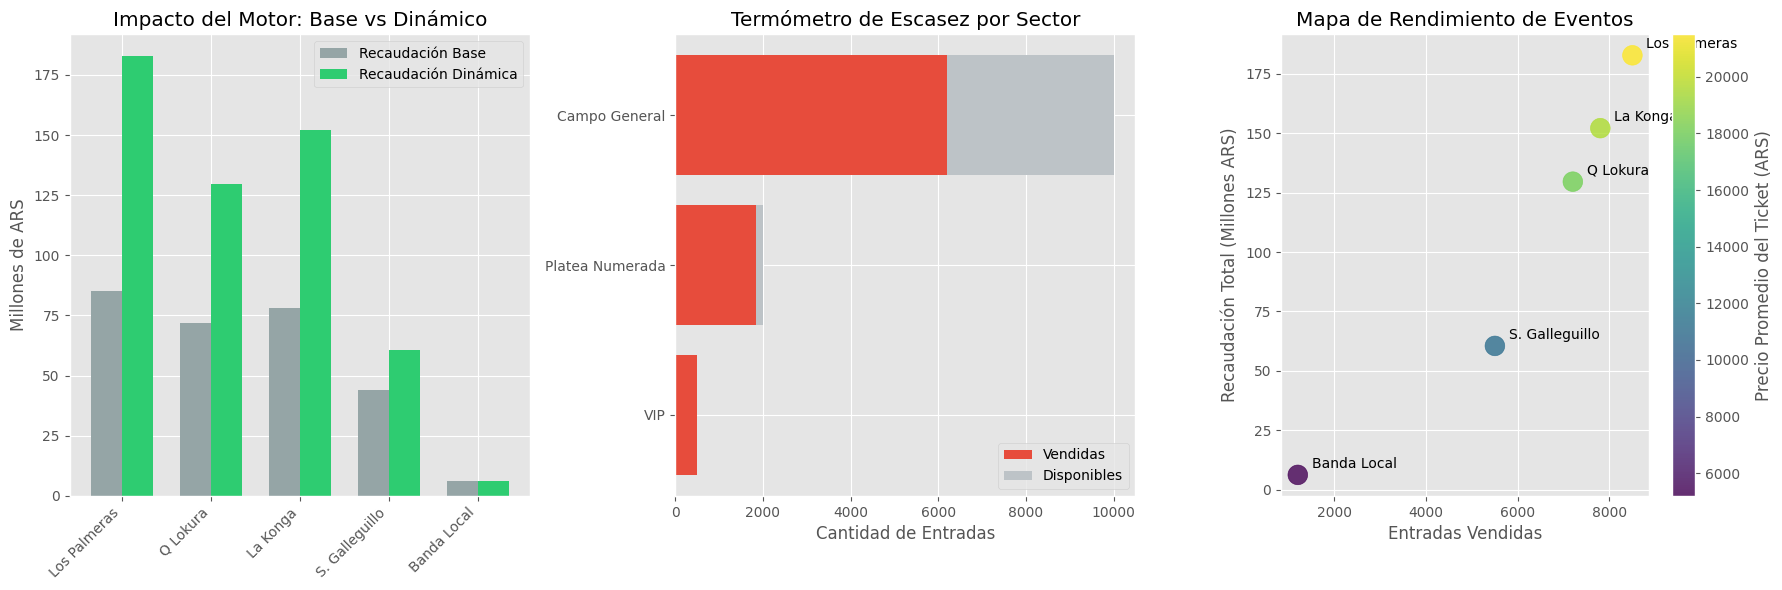

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo visual más moderno para los gráficos
plt.style.use('ggplot')

# --- 1. CREACIÓN DE DATOS FALSOS ESTÁTICOS ---

# Datos globales para Eventos (Gráficos 1 y 3)
datos_eventos = {
    'artista': ['Los Palmeras', 'Q Lokura', 'La Konga', 'S. Galleguillo', 'Banda Local'],
    'entradas_vendidas': [8500, 7200, 7800, 5500, 1200],
    'precio_base_ars': [10000, 10000, 10000, 8000, 5000],
    # Simulamos el precio promedio real pagado gracias a tu motor
    'precio_prom_dinamico': [21500, 18000, 19500, 11000, 5200]
}
df_eventos = pd.DataFrame(datos_eventos)

# Cálculos de recaudación
df_eventos['recaudacion_estatica'] = df_eventos['entradas_vendidas'] * df_eventos['precio_base_ars']
df_eventos['recaudacion_dinamica'] = df_eventos['entradas_vendidas'] * df_eventos['precio_prom_dinamico']

# Datos de un solo evento para el análisis de sectores (Gráfico 2)
datos_sectores = {
    'sector': ['VIP', 'Platea Numerada', 'Campo General'],
    'capacidad': [500, 2000, 10000],
    'vendidas': [490, 1850, 6200]
}
df_sectores = pd.DataFrame(datos_sectores)
df_sectores['disponibles'] = df_sectores['capacidad'] - df_sectores['vendidas']

# --- 2. RENDERIZADO DE GRÁFICOS ---

# Creamos una figura con 3 sub-gráficos (1 fila, 3 columnas)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# GRÁFICO 1: Recargo vs Base (Barras agrupadas)
x = np.arange(len(df_eventos['artista']))
ancho = 0.35

ax1.bar(x - ancho/2, df_eventos['recaudacion_estatica'] / 1e6, ancho, label='Recaudación Base', color='#95a5a6')
ax1.bar(x + ancho/2, df_eventos['recaudacion_dinamica'] / 1e6, ancho, label='Recaudación Dinámica', color='#2ecc71')

ax1.set_title('Impacto del Motor: Base vs Dinámico')
ax1.set_ylabel('Millones de ARS')
ax1.set_xticks(x)
ax1.set_xticklabels(df_eventos['artista'], rotation=45, ha='right')
ax1.legend()

# GRÁFICO 2: Escasez por Sector (Barras apiladas horizontales)
ax2.barh(df_sectores['sector'], df_sectores['vendidas'], color='#e74c3c', label='Vendidas')
ax2.barh(df_sectores['sector'], df_sectores['disponibles'], left=df_sectores['vendidas'], color='#bdc3c7', label='Disponibles')

ax2.set_title('Termómetro de Escasez por Sector')
ax2.set_xlabel('Cantidad de Entradas')
ax2.legend()

# GRÁFICO 3: Dispersión (Ventas vs Ganancias)
scatter = ax3.scatter(
    df_eventos['entradas_vendidas'], 
    df_eventos['recaudacion_dinamica'] / 1e6, 
    c=df_eventos['precio_prom_dinamico'], # El color cambia según el precio del ticket
    cmap='viridis', 
    s=200, # Tamaño de los puntos
    alpha=0.8
)

# Etiquetas para los puntos
for i, txt in enumerate(df_eventos['artista']):
    ax3.annotate(txt, (df_eventos['entradas_vendidas'][i], df_eventos['recaudacion_dinamica'][i] / 1e6), 
                 xytext=(10, 5), textcoords='offset points')

ax3.set_title('Mapa de Rendimiento de Eventos')
ax3.set_xlabel('Entradas Vendidas')
ax3.set_ylabel('Recaudación Total (Millones ARS)')
fig.colorbar(scatter, ax=ax3, label='Precio Promedio del Ticket (ARS)')

# Ajustamos el layout para que no se pisen los textos y mostramos
plt.tight_layout()
plt.show()

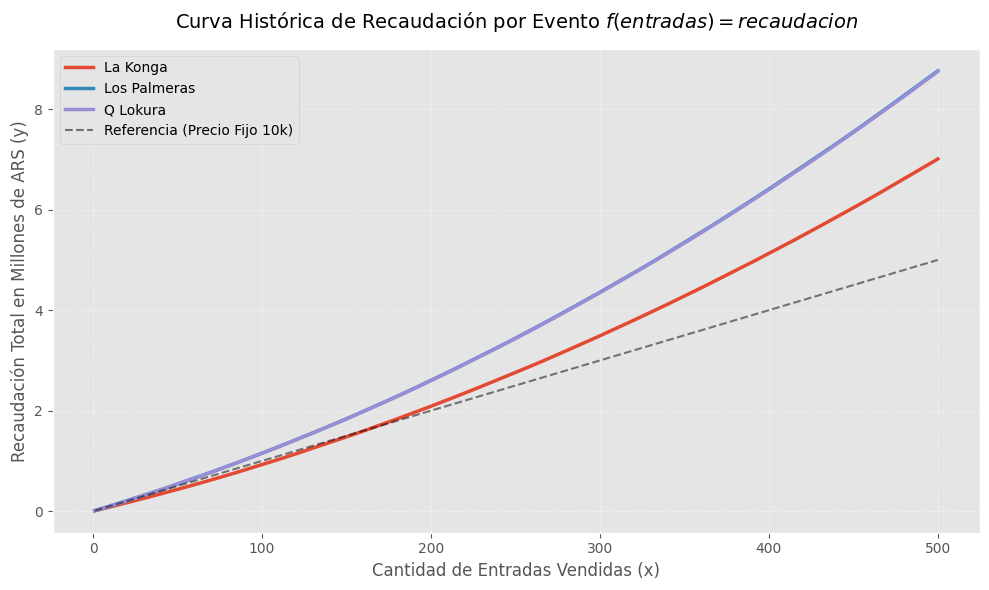

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

# --- 1. SIMULADOR DE HISTORIAL DE VENTAS (TICKETS) ---
# Vamos a simular 3 eventos vendiendo entradas una por una.
eventos_simulados = ['Los Palmeras', 'Q Lokura', 'La Konga']
datos_tickets = []

for evento in eventos_simulados:
    precio_base = 10000 if evento != 'La Konga' else 8000
    
    # Simulamos la venta de 500 entradas por evento
    for n_entrada in range(1, 501):
        # Simulamos tu motor dinámico: a medida que se venden (n_entrada sube),
        # el precio se encarece. Agregamos un poco de ruido aleatorio.
        recargo_dinamico = (n_entrada / 500) * 1.5  # Sube hasta un 150% extra
        precio_pagado = precio_base * (1 + recargo_dinamico) + np.random.randint(-500, 500)
        
        datos_tickets.append({
            'evento': evento,
            'precio_pagado': precio_pagado
        })

# Convertimos a un DataFrame (esto es similar a lo que sacaremos del ORM de Django)
df_tickets = pd.DataFrame(datos_tickets)

# --- 2. EL CÁLCULO ACUMULATIVO f(x) = y ---

plt.figure(figsize=(10, 6))

# Agrupamos por evento y calculamos la suma acumulada
for nombre_evento, df_grupo in df_tickets.groupby('evento'):
    # Reseteamos el índice para que sea 1, 2, 3... (Eje X: Entradas Vendidas)
    df_grupo = df_grupo.reset_index(drop=True)
    df_grupo.index += 1 
    
    # Eje Y: Suma acumulada de la plata (Recaudación Total Histórica)
    recaudacion_acumulada = df_grupo['precio_pagado'].cumsum()
    
    # Dibujamos la función
    plt.plot(df_grupo.index, recaudacion_acumulada / 1e6, 
             linewidth=2.5, label=f'{nombre_evento}')

# --- 3. DISEÑO DEL GRÁFICO ---
plt.title('Curva Histórica de Recaudación por Evento $f(entradas) = recaudacion$', fontsize=14, pad=15)
plt.xlabel('Cantidad de Entradas Vendidas (x)', fontsize=12)
plt.ylabel('Recaudación Total en Millones de ARS (y)', fontsize=12)

# Agregamos una línea de referencia: Cómo se vería si NO hubiera precios dinámicos
# (Una línea recta perfecta usando un precio base de 10000)
x_referencia = np.arange(1, 501)
y_referencia = (x_referencia * 10000) / 1e6
plt.plot(x_referencia, y_referencia, color='black', linestyle='--', alpha=0.5, 
         label='Referencia (Precio Fijo 10k)')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()